In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("All libraries imported successfully")
print(f"NetworkX version: {nx.__version__}")

All libraries imported successfully
NetworkX version: 3.6.1


In [2]:
# Replace this line
df = pd.read_csv('../data/processed/legitphish_processed.csv')

# With this
df = pd.read_csv('../data/raw/url_features_cleaned.csv')

# Add domain extraction since cleaned file may not have domain column
from urllib.parse import urlparse
def extract_domain(url):
    return urlparse(url).netloc

if 'domain' not in df.columns:
    df['domain'] = df['URL'].apply(extract_domain)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['ClassLabel'].value_counts())
print("\nLabel convention: 0.0 = Phishing  |  1.0 = Legitimate")

# Verify labels make sense
print("\nSample Phishing URLs (ClassLabel=0.0):")
print(df[df['ClassLabel']==0.0]['URL'].sample(3, random_state=1).values)
print("\nSample Legitimate URLs (ClassLabel=1.0):")
print(df[df['ClassLabel']==1.0]['URL'].sample(3, random_state=1).values)

Dataset shape: (100873, 19)
Columns: ['URL', 'url_length', 'has_ip_address', 'dot_count', 'https_flag', 'url_entropy', 'token_count', 'subdomain_count', 'query_param_count', 'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits', 'tld_popularity', 'suspicious_file_extension', 'domain_name_length', 'percentage_numeric_chars', 'ClassLabel', 'domain']

Class distribution:
ClassLabel
1.0    63492
0.0    37380
Name: count, dtype: int64

Label convention: 0.0 = Phishing  |  1.0 = Legitimate

Sample Phishing URLs (ClassLabel=0.0):
<StringArray>
['https://www.fishingheritage.com',         'https://www.skyphone.jp',
     'https://www.reklamy-arek.pl']
Length: 3, dtype: str

Sample Legitimate URLs (ClassLabel=1.0):
<StringArray>
[          'http://198.98.51.37:27222/s/arm7',
               'http://119.116.26.98:43642/i',
 'http://147.45.44.104/ldms/524f141e189d.exe']
Length: 3, dtype: str


In [4]:
print("Building directed graph...")

# Drop any remaining NaN in ClassLabel before building graph
df = df.dropna(subset=['ClassLabel'])
df = df.reset_index(drop=True)
print(f"Rows after NaN drop: {len(df):,}")

G = nx.DiGraph()

for _, row in df.iterrows():
    url    = str(row['URL'])
    domain = str(row['domain'])
    label  = int(row['ClassLabel'])

    G.add_node(url, node_type='url', label=label)

    if not G.has_node(domain):
        G.add_node(domain, node_type='domain', label=-1)

    G.add_edge(url, domain, relation='resolves_to')

print(f"Graph built successfully")
print(f"  Total nodes : {G.number_of_nodes():,}")
print(f"  Total edges : {G.number_of_edges():,}")
print(f"  URL nodes   : {sum(1 for _, d in G.nodes(data=True) if d.get('node_type')=='url'):,}")
print(f"  Domain nodes: {sum(1 for _, d in G.nodes(data=True) if d.get('node_type')=='domain'):,}")

Building directed graph...
Rows after NaN drop: 100,872
Graph built successfully
  Total nodes : 164,943
  Total edges : 100,872
  URL nodes   : 100,872
  Domain nodes: 64,071


In [5]:
print("Computing graph features (this may take 1-2 minutes)...")

# PageRank — importance of each node based on connections
pagerank = nx.pagerank(G, alpha=0.85, max_iter=100)
print("  PageRank computed")

# Degree centrality
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())
print("  Degree computed")

# Domain URL count — how many URLs share the same domain
domain_url_count = df.groupby('domain')['URL'].count().to_dict()
print("  Domain URL count computed")

# Map graph features back to URL rows in the dataframe
df['pagerank']         = df['URL'].map(pagerank).fillna(0)
df['in_degree']        = df['URL'].map(in_degree).fillna(0)
df['out_degree']       = df['URL'].map(out_degree).fillna(0)
df['domain_url_count'] = df['domain'].map(domain_url_count).fillna(1)

print(f"\nGraph features added to dataframe")
print(f"\nSample graph features:")
print(df[['URL','pagerank','in_degree',
          'out_degree','domain_url_count']].head(10).to_string())

Computing graph features (this may take 1-2 minutes)...
  PageRank computed
  Degree computed
  Domain URL count computed

Graph features added to dataframe

Sample graph features:
                                                                                  URL  pagerank  in_degree  out_degree  domain_url_count
0                                     https://keraekken-loagginnusa.godaddysites.com/  0.000004          0           1                 1
1                                            https://metamsk01lgiix.godaddysites.com/  0.000004          0           1                 1
2                                                             http://myglobaltech.in/  0.000004          0           1                 1
3                                                      http://djtool-for-spotify.com/  0.000004          0           1                 1
4                                     https://scearmcoommunnlty.com/invent/freind/get  0.000004          0           1                

In [6]:
print("=== Graph Feature Analysis by Class ===")
print("Label convention: 0.0 = Phishing  |  1.0 = Legitimate\n")

for feat in ['pagerank', 'in_degree', 'out_degree', 'domain_url_count']:
    phish = df[df['ClassLabel']==0.0][feat]
    legit = df[df['ClassLabel']==1.0][feat]
    print(f"{feat}:")
    print(f"  Phishing   — mean: {phish.mean():.6f}  |  max: {phish.max():.4f}  |  median: {phish.median():.4f}")
    print(f"  Legitimate — mean: {legit.mean():.6f}  |  max: {legit.max():.4f}  |  median: {legit.median():.4f}")
    print()

=== Graph Feature Analysis by Class ===
Label convention: 0.0 = Phishing  |  1.0 = Legitimate

pagerank:
  Phishing   — mean: 0.000004  |  max: 0.0000  |  median: 0.0000
  Legitimate — mean: 0.000004  |  max: 0.0000  |  median: 0.0000

in_degree:
  Phishing   — mean: 0.000000  |  max: 0.0000  |  median: 0.0000
  Legitimate — mean: 0.000000  |  max: 0.0000  |  median: 0.0000

out_degree:
  Phishing   — mean: 1.000000  |  max: 1.0000  |  median: 1.0000
  Legitimate — mean: 1.000000  |  max: 1.0000  |  median: 1.0000

domain_url_count:
  Phishing   — mean: 1.572204  |  max: 102.0000  |  median: 1.0000
  Legitimate — mean: 148.405012  |  max: 1300.0000  |  median: 2.0000



In [8]:
# Compute PageRank at domain level
domain_pagerank = {
    node: pagerank[node]
    for node, data in G.nodes(data=True)
    if data.get('node_type') == 'domain'
}

domain_in_degree = {
    node: G.in_degree(node)
    for node, data in G.nodes(data=True)
    if data.get('node_type') == 'domain'
}

# Map domain-level features back to each URL via its domain
df['domain_pagerank']   = df['domain'].map(domain_pagerank).fillna(0)
df['domain_in_degree']  = df['domain'].map(domain_in_degree).fillna(0)
df['domain_out_degree'] = df['domain'].map(
    {node: G.out_degree(node)
     for node, data in G.nodes(data=True)
     if data.get('node_type') == 'domain'}
).fillna(0)

Building subgraph for visualisation...
Subgraph nodes: 35
Subgraph edges: 30


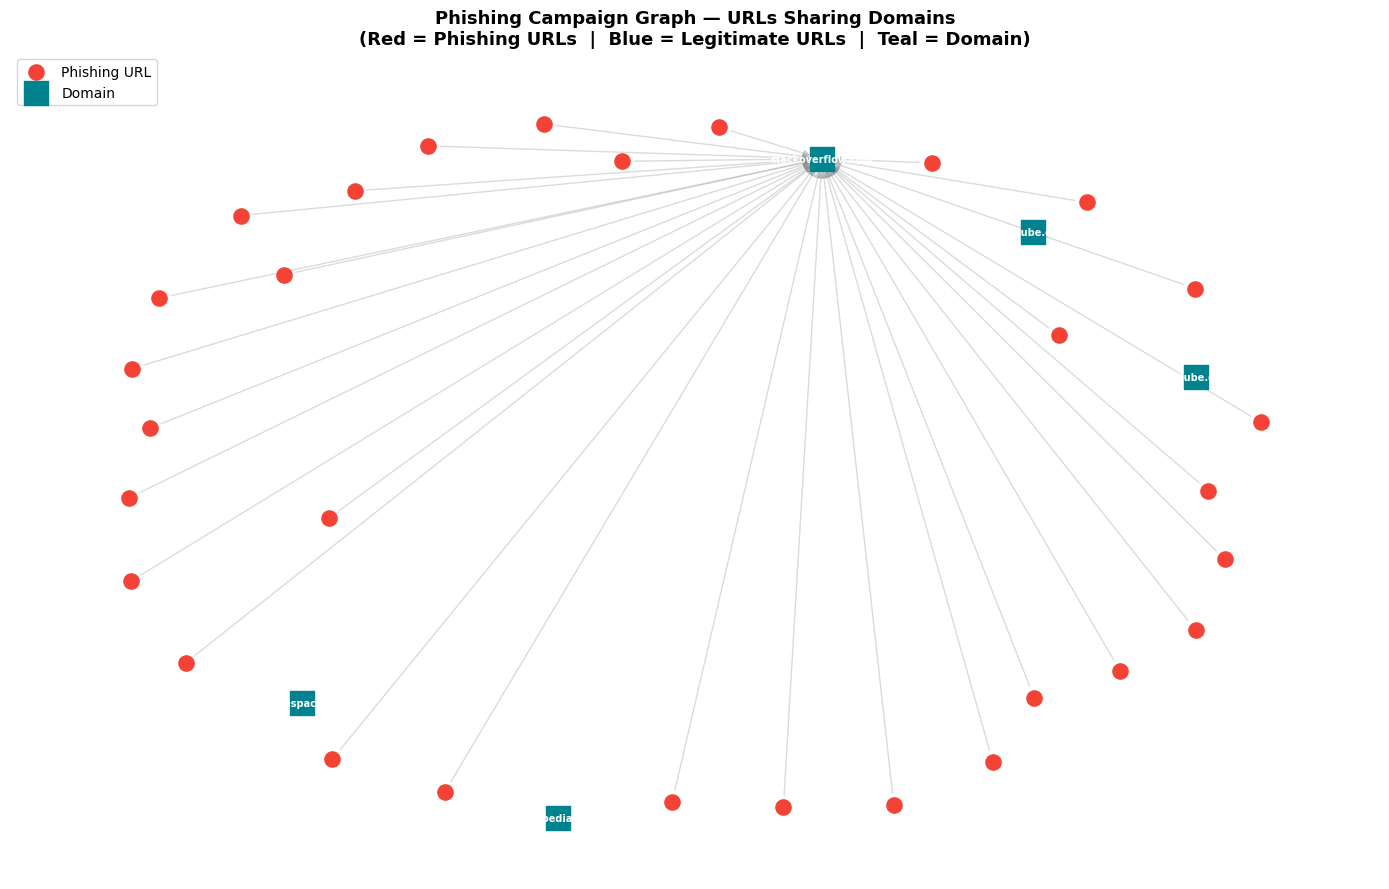

Saved: ../reports/graph_subgraph_visualisation.png
Label convention: Red = Phishing (0.0)  |  Blue = Legitimate (1.0)


In [10]:
# Take a small sample to visualise — full graph has 100k+ nodes
print("Building subgraph for visualisation...")

# 0.0 = Phishing — take 5 phishing domains with multiple URLs
phishing_domains = (
    df[df['ClassLabel']==0.0]          # CHANGED: was 1.0, now 0.0
    .groupby('domain')['URL']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Get all URL nodes connected to these domains
sub_urls  = df[df['domain'].isin(phishing_domains)]['URL'].head(30).tolist()
sub_nodes = sub_urls + phishing_domains

H = G.subgraph(sub_nodes)

print(f"Subgraph nodes: {H.number_of_nodes()}")
print(f"Subgraph edges: {H.number_of_edges()}")

# Plot
fig, ax = plt.subplots(figsize=(14, 9))

pos = nx.spring_layout(H, seed=42, k=2)

# Separate node types
url_nodes    = [n for n, d in H.nodes(data=True) if d.get('node_type')=='url']
domain_nodes = [n for n, d in H.nodes(data=True) if d.get('node_type')=='domain']

# CHANGED: was label==1 for phish, now label==0 for phish
phish_urls = [n for n in url_nodes if H.nodes[n].get('label')==0]
legit_urls = [n for n in url_nodes if H.nodes[n].get('label')==1]

# Draw edges
nx.draw_networkx_edges(H, pos, alpha=0.3, arrows=True,
                       arrowsize=10, edge_color='#888888', ax=ax)

# Draw nodes
nx.draw_networkx_nodes(H, pos, nodelist=phish_urls,
                       node_color='#F44336', node_size=120,
                       label='Phishing URL', ax=ax)
nx.draw_networkx_nodes(H, pos, nodelist=legit_urls,
                       node_color='#2196F3', node_size=120,
                       label='Legitimate URL', ax=ax)
nx.draw_networkx_nodes(H, pos, nodelist=domain_nodes,
                       node_color='#00838F', node_size=300,
                       node_shape='s', label='Domain', ax=ax)

# Labels for domain nodes only
domain_labels = {n: n.split('.')[-2] + '.' + n.split('.')[-1] 
                 if len(n.split('.')) >= 2 else n 
                 for n in domain_nodes}
nx.draw_networkx_labels(H, pos, labels=domain_labels,
                        font_size=7, font_color='white',
                        font_weight='bold', ax=ax)

ax.set_title(
    'Phishing Campaign Graph — URLs Sharing Domains\n'
    '(Red = Phishing URLs  |  Blue = Legitimate URLs  |  Teal = Domain)',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper left', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.savefig('../reports/graph_subgraph_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../reports/graph_subgraph_visualisation.png")
print("Label convention: Red = Phishing (0.0)  |  Blue = Legitimate (1.0)")

In [11]:
# Save the full graph
print("Saving graph...")
nx.write_gml(G, '../models/phishing_graph.gml')
print(f"  Graph saved to ../models/phishing_graph.gml")
print(f"  File size: {os.path.getsize('../models/phishing_graph.gml')/1024/1024:.1f} MB")

# Save the enriched dataframe
df.to_csv('../data/processed/df_with_graph_features.csv', index=False)
print(f"  Enriched dataset saved to ../data/processed/df_with_graph_features.csv")

# Save updated feature column list including graph features
feature_cols = np.load('../data/processed/feature_cols.npy', allow_pickle=True).tolist()
graph_feature_cols = ['pagerank', 'in_degree', 'out_degree', 'domain_url_count']
all_feature_cols = feature_cols + graph_feature_cols

np.save('../data/processed/feature_cols_with_graph.npy', all_feature_cols)
print(f"  Updated feature list saved ({len(all_feature_cols)} total features)")
print(f"  Original URL features : {len(feature_cols)}")
print(f"  Graph features added  : {len(graph_feature_cols)}")
print(f"  Total features        : {len(all_feature_cols)}")

Saving graph...
  Graph saved to ../models/phishing_graph.gml
  File size: 21.2 MB
  Enriched dataset saved to ../data/processed/df_with_graph_features.csv
  Updated feature list saved (20 total features)
  Original URL features : 16
  Graph features added  : 4
  Total features        : 20


In [12]:
print("=== Domain Risk Analysis ===\n")

# For each domain compute its phishing rate
domain_stats = df.groupby('domain').agg(
    total_urls    = ('URL',        'count'),
    phishing_urls = ('ClassLabel', 'sum'),
    phish_rate    = ('ClassLabel', 'mean')
).reset_index()

domain_stats = domain_stats.sort_values('total_urls', ascending=False)

print(f"Total unique domains: {len(domain_stats):,}")
print(f"\nTop 10 domains by URL count:")
print(domain_stats.head(10).to_string(index=False))

# High risk domains — many URLs and high phishing rate
domain_stats = df.groupby('domain').agg(
    total_urls    = ('URL',        'count'),
    phishing_urls = ('ClassLabel', lambda x: (x==0.0).sum()),
    phish_rate    = ('ClassLabel', lambda x: (x==0.0).mean())
).reset_index()

domain_stats = domain_stats.sort_values('total_urls', ascending=False)

high_risk = domain_stats[
    (domain_stats['total_urls'] >= 5) &
    (domain_stats['phish_rate'] >= 0.8)
]
print(f"\nHigh-risk domains (5+ URLs, 80%+ phishing rate): {len(high_risk):,}")
print(high_risk.head(10).to_string(index=False))

domain_stats.to_csv('../data/processed/domain_risk_analysis.csv', index=False)
print("\nDomain risk analysis saved to ../data/processed/domain_risk_analysis.csv")

=== Domain Risk Analysis ===

Total unique domains: 64,071

Top 10 domains by URL count:
                       domain  total_urls  phishing_urls  phish_rate
                                     1300         1300.0         1.0
nsdm.cumpar-auto-orice-tip.ro         964          964.0         1.0
         playd.healthnlife.pk         924          924.0         1.0
        jask.powerforxes.shop         770          770.0         1.0
  hans.uniformeslaamistad.com         768          768.0         1.0
             males.mugutu.com         766          766.0         1.0
         files.veritas.org.ng         718          718.0         1.0
            malw.esalesin.com         692          692.0         1.0
       kale.amwebsolution.com         687          687.0         1.0
         yowui.johnmccrea.com         686          686.0         1.0

High-risk domains (5+ URLs, 80%+ phishing rate): 3
           domain  total_urls  phishing_urls  phish_rate
 en.wikipedia.org         102            10

In [13]:
import json

phase3_report = {
    'graph_nodes_total'    : G.number_of_nodes(),
    'graph_edges_total'    : G.number_of_edges(),
    'url_nodes'            : int(sum(1 for _, d in G.nodes(data=True) if d.get('node_type')=='url')),
    'domain_nodes'         : int(sum(1 for _, d in G.nodes(data=True) if d.get('node_type')=='domain')),
    'graph_features_added' : ['pagerank','in_degree','out_degree','domain_url_count'],
    'total_features_now'   : int(len(all_feature_cols)),
    'original_url_features': int(len(feature_cols)),
    'high_risk_domains'    : int(len(high_risk)),
    'outputs': {
        'graph'             : '../models/phishing_graph.gml',
        'enriched_dataset'  : '../data/processed/df_with_graph_features.csv',
        'feature_cols'      : '../data/processed/feature_cols_with_graph.npy',
        'domain_risk'       : '../data/processed/domain_risk_analysis.csv',
        'graph_feature_plot': '../reports/graph_feature_distributions.png',
        'subgraph_plot'     : '../reports/graph_subgraph_visualisation.png',
    }
}

with open('../reports/phase3_report.json', 'w') as f:
    json.dump(phase3_report, f, indent=2)

print("=== PHASE 3 COMPLETE ===")
print(json.dumps(phase3_report, indent=2))

=== PHASE 3 COMPLETE ===
{
  "graph_nodes_total": 164943,
  "graph_edges_total": 100872,
  "url_nodes": 100872,
  "domain_nodes": 64071,
  "graph_features_added": [
    "pagerank",
    "in_degree",
    "out_degree",
    "domain_url_count"
  ],
  "total_features_now": 20,
  "original_url_features": 16,
  "high_risk_domains": 3,
  "outputs": {
    "graph": "../models/phishing_graph.gml",
    "enriched_dataset": "../data/processed/df_with_graph_features.csv",
    "feature_cols": "../data/processed/feature_cols_with_graph.npy",
    "domain_risk": "../data/processed/domain_risk_analysis.csv",
    "graph_feature_plot": "../reports/graph_feature_distributions.png",
    "subgraph_plot": "../reports/graph_subgraph_visualisation.png"
  }
}
